In [1]:
%%capture --no-stderr
%pip install --upgrade --force-reinstall langgraph
%pip install --quiet -U langchain_openai langchain_core
%pip install requests

In [20]:
%pip install tavily-python

curl https://llmexecution.api.intuit.com/v3/models

## Generate an Access Token by running the following curl command either in the terminal or postman/intuit api client

### Note - First replace the app_secret in the command with secret shared in TinCan







```
curl --location 'https://identityinternal.api.intuit.com/signin/graphql' --header 'Authorization: Intuit_IAM_Authentication intuit_appid="Intuit.aifabric.genos.agenticaitrainingclient",intuit_app_secret=prdFtgimomcXJHvKvJo80831nB6FINieM2HKkGwO' --header 'Content-Type: application/json' --data-raw '{"query":"mutation identityTestSignInWithPassword($input: Identity_TestSignInWithPasswordInput!) {\n identityTestSignInWithPassword(input: $input) {\n accessToken\n legacyAuthId\n}\n}","variables":{"input":{"username":"iamtestpass_616829375333307","password":"Intuit01-","tenantId":"50000003","intent":{"appGroup":"QBO","assetAlias":"Intuit.aifabric.genos.agenticaitrainingclient"}}}}'
```




## Generate the PrivateAuth+ headers for calling the LLM
### Note - First replace the intuit_app_secret and intuit_token fields in the AUTHN_STRING below with the app_secret shared in TinCan and accessToken fromt the previous step

In [3]:
# Intuit PrivateAuth+ headers
# Use the Access Token from the previous cell in the intuit_token_type field
AUTHN_STRING = "Intuit_IAM_Authentication " \
               "intuit_appid='Intuit.aifabric.genos.agenticaitrainingclient'," \
               "intuit_app_secret='prdFtgimomcXJHvKvJo80831nB6FINieM2HKkGwO'," \
               "intuit_token_type='IAM-Ticket'," \
               f"intuit_userid=4621097838312242983," \
               f"intuit_token=V1-142-B0nh4rgfcfpkyi5m2x7qxx"

INTUIT_AUTHN_HEADERS = {
    "Authorization": AUTHN_STRING,
    "intuit_experience_id": "c1392e45-9ef3-4d87-9e6f-3dd45294e545", # GenOS experience_id
    "intuit_originating_assetalias": "Intuit.aifabric.genos.agenticaitrainingclient"
}

## Define tools and bind to LLM

In [33]:
from langchain_openai import ChatOpenAI
from tavily import TavilyClient
import sqlite3

def execute_query(sql: str):
  """
  Execute a sql query on the sqlite database and return the result

  Args:
    sql: The sql query to execute

  Returns:
    The result of the query
  """
  print(f"SQL: {sql}")
  with sqlite3.connect("llm_kb.db", check_same_thread=False) as con:
    try:
      cur = con.cursor()
      res = cur.execute(sql)
      con.commit() # Commit changes for DDL operations
      return res.fetchall()
    except sqlite3.OperationalError as e:
      # Check if the error is due to the table already existing and if it's a CREATE TABLE statement
      if "table knowledge_base already exists" in str(e) and "CREATE TABLE" in sql.upper():
        print(f"Table 'knowledge_base' already exists. Skipping creation.")
        return [] # Return an empty list as there's no result from a failed CREATE TABLE
      else:
        raise e # Re-raise other unexpected operational errors

def web_search(query: str):
  """
  Search the web for the given query and return the results

  Args:
    query: The query to search for

  Returns:
    The results of the search
  """
  tavily_client = TavilyClient(api_key="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")
  response = tavily_client.search(query)
  print(response)


tools = [execute_query, web_search]

llm = ChatOpenAI(
    api_key="anything",  # No OP as we will use Intuit AuthN headers
    model="xxxx",  # No OP as model id is in path param
    base_url="https://llmexecution.api.intuit.com/v3/gpt-4o-2024-05-13/",
    temperature=0,
    max_tokens=4096,
    extra_headers={
        **INTUIT_AUTHN_HEADERS
    })

llm_with_tools = llm.bind_tools(tools)

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3473: UserWarning: WARNING! extra_headers is not default parameter.
                extra_headers was transferred to model_kwargs.
                Please confirm that extra_headers is what you intended.
  if (await self.run_code(code, result,  async_=asy)):


## Add assistant

In [38]:
from langgraph.graph import MessagesState
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(
    content="""
    You are a helpful assistant tasked with creating a knowledge base using sqlite tools to store knowledge given to you.
    Do not add any other additional info to it.
    Check the schema of the table before inserting the data and then construct the insert query correctly for the columns.

    Do not drop any tables or delete any existing records.
    """)

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

## Build the graph

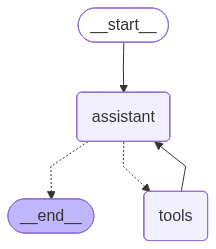

In [39]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile(debug=True)

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

## Invoke the agent

In [36]:
## tracer goes here
messages = [HumanMessage(content="""
Find 10 animal facts on web and add it to the knowledge base.
""")]
messages = react_graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

[values] {'messages': [HumanMessage(content='\nFind 10 animal facts and add it to the knowledge base.\n', additional_kwargs={}, response_metadata={}, id='a65b5ab2-caae-4bbd-a5ae-d9f849476336')]}
[updates] {'assistant': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 162, 'total_tokens': 212, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'text_tokens': None, 'image_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_3eed281ddb', 'id': 'chatcmpl-CbDq6xDSWka73DVIabKgPaziv3BEU', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--99154e15-6506-4eb1-9fe0-b9f847f7adf9-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'interesting animal facts'}, 

In [40]:
messages = [HumanMessage(content="""
Fetch all records from the knowledge base for animal facts
""")]
messages = react_graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

[values] {'messages': [HumanMessage(content='\nFetch all records from the knowledge base for animal facts\n', additional_kwargs={}, response_metadata={}, id='50a0874a-ff9b-4a94-a985-82269d3d2de7')]}
[updates] {'assistant': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 172, 'total_tokens': 193, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'text_tokens': None, 'image_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_f353efaf53', 'id': 'chatcmpl-CbDsGlWqvTOKDElixNQwZr2pvMecV', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--ddf74248-8a31-4519-ad39-691b4bb73a20-0', tool_calls=[{'name': 'execute_query', 'args': {'sql': 'SELECT * FROM animal_fa